# ĐỒ ÁN HỌC MÁY: CHẨN ĐOÁN BỆNH THẬN


### Phần 1 — Setup & Import Thư viện
Import các thư viện xử lý dữ liệu, phân tách tập train/test, mô hình cây, tối ưu siêu tham số, trực quan hóa và lưu trữ mô hình.


In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_validate
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# LightGBM
from lightgbm import LGBMClassifier

# Cấu hình cảnh báo & hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Tạo thư mục outputs nếu chưa có
os.makedirs('outputs', exist_ok=True)

print("✅ Setup & Import thư viện thành công!")


✅ Setup & Import thư viện thành công!


### Phần 2 — Đọc Dữ liệu Đã Xử lý
- Đọc file dữ liệu đầu vào `data/clean_KidneyDisease_data.csv`.
- Kiểm tra kích thước dữ liệu (`.shape`).
- Kiểm tra giá trị khuyết thiếu (`.isnull().sum()`) — đảm bảo 100% không còn missing values.
- Kiểm tra kiểu dữ liệu (`.dtypes`) — đảm bảo toàn bộ đã được mã hóa sang dạng số.


In [2]:
# Đọc file dữ liệu 
data_path = 'data/clean_KidneyDisease_data.csv'
df = pd.read_csv(data_path)

print(f"📊 Kích thước dữ liệu (Shape): {df.shape[0]} dòng, {df.shape[1]} cột")

# 1. Kiểm tra giá trị khuyết thiếu
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("✅ Kiểm tra Missing Values: ĐẠT (Không còn giá trị khuyết thiếu)")
else:
    print(f"❌ CẢNH BÁO: Còn {missing_count} giá trị thiếu cần xử lý!")
    display(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Kiểm tra kiểu dữ liệu chuỗi (object)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
if len(object_cols) == 0:
    print("✅ Kiểm tra Dtypes: ĐẠT (100% các cột đã được mã hóa sang dạng số)")
else:
    print(f"❌ CẢNH BÁO: Còn {len(object_cols)} cột kiểu chữ chưa encode: {object_cols}")

# Hiển thị 5 dòng đầu tiên
df.head()


📊 Kích thước dữ liệu (Shape): 397 dòng, 25 cột
✅ Kiểm tra Missing Values: ĐẠT (Không còn giá trị khuyết thiếu)
✅ Kiểm tra Dtypes: ĐẠT (100% các cột đã được mã hóa sang dạng số)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,1,0,0,1,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,1,0,0,1,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,1,2,0,2,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,1,2,1,2,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,1,0,0,1,0


### Phần 3 — Chia Tập Train / Test
- Tách ma trận đặc trưng $X$ (bỏ cột nhãn `class`) và nhãn mục tiêu $y$.
- Sử dụng `train_test_split` với tỷ lệ:
  - `test_size = 0.2` (80% Train — 20% Test)
  - `random_state = 42` (Đảm bảo tính tái lập)
  - `stratify = y` (**Bắt buộc**: bảo toàn tỷ lệ lớp bệnh/khỏe giữa 2 tập do dữ liệu mất cân bằng)
- **Lưu ý y khoa**: Trong dataset, `class = 0` là CKD (Có bệnh), `class = 1` là NotCKD (Không bệnh/Khỏe mạnh).


In [3]:
TARGET_COL = 'class'

# Tách X và y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Phân chia train/test có stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Số lượng mẫu tập Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Số lượng mẫu tập Test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("-" * 50)

# Kiểm tra tỷ lệ phân phối nhãn
train_dist = y_train.value_counts(normalize=True).round(4) * 100
test_dist = y_test.value_counts(normalize=True).round(4) * 100

dist_df = pd.DataFrame({
    'Train (%)': train_dist,
    'Test (%)': test_dist
})
dist_df.index = [f"Class {idx} ({'CKD - Có bệnh' if idx == 0 else 'NotCKD - Khỏe'})" for idx in dist_df.index]
print("Tỷ lệ phân bố nhãn (Stratified Verification):")
display(dist_df)


Số lượng mẫu tập Train: 317 (79.8%)
Số lượng mẫu tập Test:  80 (20.2%)
--------------------------------------------------
Tỷ lệ phân bố nhãn (Stratified Verification):


,Train (%),Test (%)
Class 0 (CKD - Có bệnh),62.46,62.5
Class 1 (NotCKD - Khỏe),37.54,37.5


### Phần 4 — Mô hình 1: Decision Tree (Baseline)
- Khởi tạo `DecisionTreeClassifier(random_state=42)` với các tham số mặc định.
- Huấn luyện trên tập Train và dự đoán trên tập Test.
- Decision Tree dùng làm mô hình chuẩn cơ sở (Baseline) để so sánh với các kỹ thuật ensemble phức tạp hơn.


In [4]:
# Huấn luyện Decision Tree baseline trên tập train.
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
print(f"🌳 Decision Tree Baseline - max_depth={dt_baseline.max_depth}")


🌳 Decision Tree Baseline - max_depth=None


### Phần 5 — Mô hình 2: Random Forest (Baseline)
- Khởi tạo `RandomForestClassifier(random_state=42)` với các tham số mặc định.
- Kỹ thuật Bagging kết hợp Feature Subsampling giúp giảm variance và hạn chế tối đa nguy cơ overfitting của cây đơn lẻ.


In [5]:
# Huấn luyện Random Forest baseline trên tập train.
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)
print(f"🌳 Random Forest Baseline - n_estimators={rf_baseline.n_estimators}")


🌳 Random Forest Baseline - n_estimators=100


### Phần 6 — Mô hình 3: LightGBM (Baseline)
- Khởi tạo `LGBMClassifier(random_state=42, verbose=-1)` với các tham số mặc định.
- Thuật toán Gradient Boosting theo cơ chế Leaf-wise growth, học tuần tự để tối ưu hóa hàm mất mát và khắc phục sai lầm của các cây trước.


In [6]:
# Huấn luyện LightGBM baseline trên tập train.
lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)
lgbm_baseline.fit(X_train, y_train)
print("⚡ LightGBM Baseline đã huấn luyện trên tập train.")


⚡ LightGBM Baseline đã huấn luyện trên tập train.


### Phần 7 — Tối ưu siêu tham số (Hyperparameter Tuning)
Tìm cấu hình bằng **Stratified 5-Fold Cross-Validation chỉ trên tập train**. Chỉ số chọn mô hình là Balanced Accuracy để cân bằng đóng góp của hai lớp. Tập test được giữ riêng, không dùng để chọn mô hình hay siêu tham số.

- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`.
- **LightGBM:** `num_leaves`, `learning_rate`, `n_estimators`.


In [7]:
# Dùng cùng một phân hoạch stratified, có shuffle và seed cố định cho mọi mô hình.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_models = {
    'Decision Tree (Baseline)': dt_baseline,
    'Random Forest (Baseline)': rf_baseline,
    'LightGBM (Baseline)': lgbm_baseline,
}

# Đo baseline bằng validation folds của tập train.
cv_metrics = {}
for model_name, estimator in baseline_models.items():
    scores = cross_validate(
        estimator, X_train, y_train, cv=cv,
        scoring='balanced_accuracy', n_jobs=1,
        return_train_score=False
    )['test_score']
    cv_metrics[model_name] = {
        'mean': float(scores.mean()),
        'std': float(scores.std(ddof=1)),
    }

# 7.1 Tối ưu siêu tham số cho Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

print("🔄 Đang tối ưu Random Forest bằng 5-Fold CV trên tập train...")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
cv_metrics['Random Forest (Tuned)'] = {
    'mean': float(rf_grid.best_score_),
    'std': float(rf_grid.cv_results_['std_test_score'][rf_grid.best_index_]),
}
print(f"✅ Random Forest - Best Params: {rf_grid.best_params_}")
print(f"✅ Random Forest - CV Balanced Accuracy: {rf_grid.best_score_:.4f} "
      f"(± {cv_metrics['Random Forest (Tuned)']['std']:.4f})")
print("-" * 60)

# 7.2 Tối ưu siêu tham số cho LightGBM
lgbm_param_grid = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

print("🔄 Đang tối ưu LightGBM bằng 5-Fold CV trên tập train...")
lgbm_grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=0
)
lgbm_grid.fit(X_train, y_train)
lgbm_best = lgbm_grid.best_estimator_
cv_metrics['LightGBM (Tuned)'] = {
    'mean': float(lgbm_grid.best_score_),
    'std': float(lgbm_grid.cv_results_['std_test_score'][lgbm_grid.best_index_]),
}
print(f"✅ LightGBM - Best Params: {lgbm_grid.best_params_}")
print(f"✅ LightGBM - CV Balanced Accuracy: {lgbm_grid.best_score_:.4f} "
      f"(± {cv_metrics['LightGBM (Tuned)']['std']:.4f})")

# Chốt mô hình theo CV trước khi mở tập test.
model_map = {
    **baseline_models,
    'Random Forest (Tuned)': rf_best,
    'LightGBM (Tuned)': lgbm_best,
}
best_model_name = max(model_map, key=lambda name: cv_metrics[name]['mean'])
best_model = model_map[best_model_name]
print(f"🏆 Mô hình được chọn theo CV Balanced Accuracy: {best_model_name} "
      f"({cv_metrics[best_model_name]['mean']:.4f} ± {cv_metrics[best_model_name]['std']:.4f})")


🔄 Đang tối ưu Random Forest bằng 5-Fold CV trên tập train...
✅ Random Forest - Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
✅ Random Forest - CV Balanced Accuracy: 0.9892 (± 0.0162)
------------------------------------------------------------
🔄 Đang tối ưu LightGBM bằng 5-Fold CV trên tập train...
✅ LightGBM - Best Params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 20}
✅ LightGBM - CV Balanced Accuracy: 0.9867 (± 0.0152)
🏆 Mô hình được chọn theo CV Balanced Accuracy: Random Forest (Baseline) (0.9892 ± 0.0181)


### Phần 8 — Xuất hình ảnh cấu trúc Decision Tree
- Trực quan hóa cây baseline bằng `plot_tree()` và cắt hình hiển thị ở `max_depth=3` cho dễ đọc.
- Cây được huấn luyện không giới hạn độ sâu; phần cắt chỉ áp dụng cho hình ảnh, không phải cấu hình huấn luyện.
- Xuất file `outputs/decision_tree_structure.png` để minh họa các luật mà cây đã học.


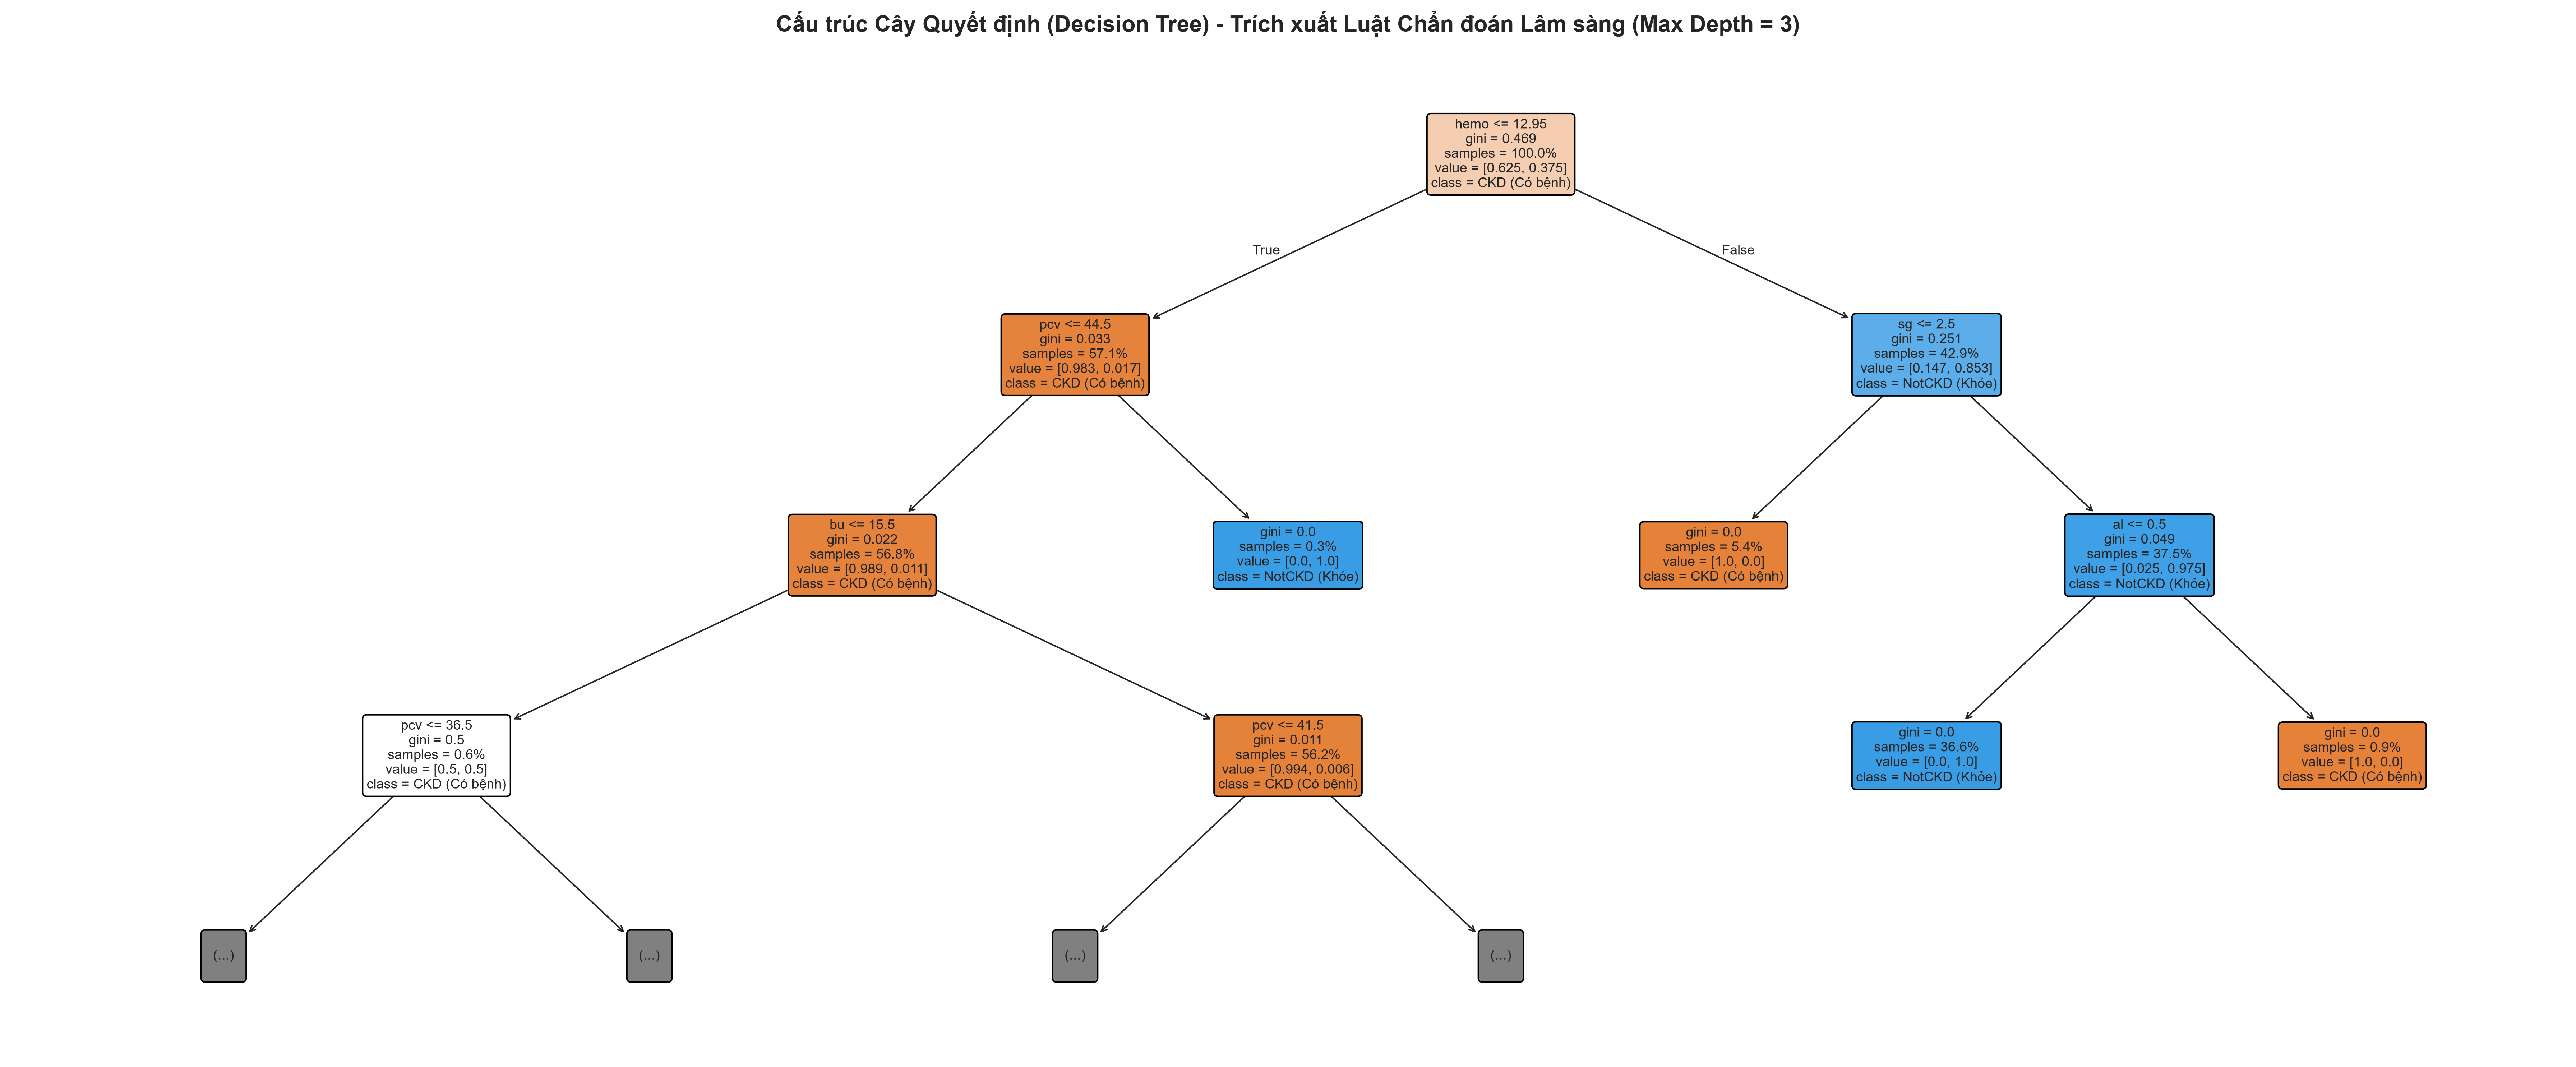

📸 Đã lưu hình ảnh cấu trúc cây tại: outputs/decision_tree_structure.png


In [8]:
# Trực quan hóa cấu trúc Decision Tree
plt.figure(figsize=(24, 10), dpi=300)

class_labels = ['CKD (Có bệnh)', 'NotCKD (Khỏe)']

plot_tree(
    dt_baseline,
    feature_names=X.columns.tolist(),
    class_names=class_labels,
    filled=True,
    rounded=True,
    max_depth=3,        # Giới hạn 3 tầng để biểu đồ rõ ràng, phục vụ báo cáo
    fontsize=9,
    proportion=True
)

plt.title("Cấu trúc Cây Quyết định (Decision Tree) - Trích xuất Luật Chẩn đoán Lâm sàng (Max Depth = 3)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()

# Lưu hình ảnh
dt_img_path = 'outputs/decision_tree_structure.png'
plt.savefig(dt_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Đã lưu hình ảnh cấu trúc cây tại: {dt_img_path}")


### Phần 9 — Biểu đồ Độ quan trọng Đặc trưng (Feature Importance)
- So sánh hiệu năng giữa Random Forest và LightGBM đã tối ưu để chọn ra mô hình xuất sắc nhất.
- Trích xuất `feature_importances_`, sắp xếp giảm dần và trực quan hóa bằng barplot.
- Hình ảnh này phục vụ viết **Chương 5.3: Phân tích các đặc trưng quan trọng**.
- Xuất file ra `outputs/feature_importance.png`.


📌 Sử dụng mô hình [Random Forest (Baseline)] đã chọn theo CV để trích xuất Feature Importance.


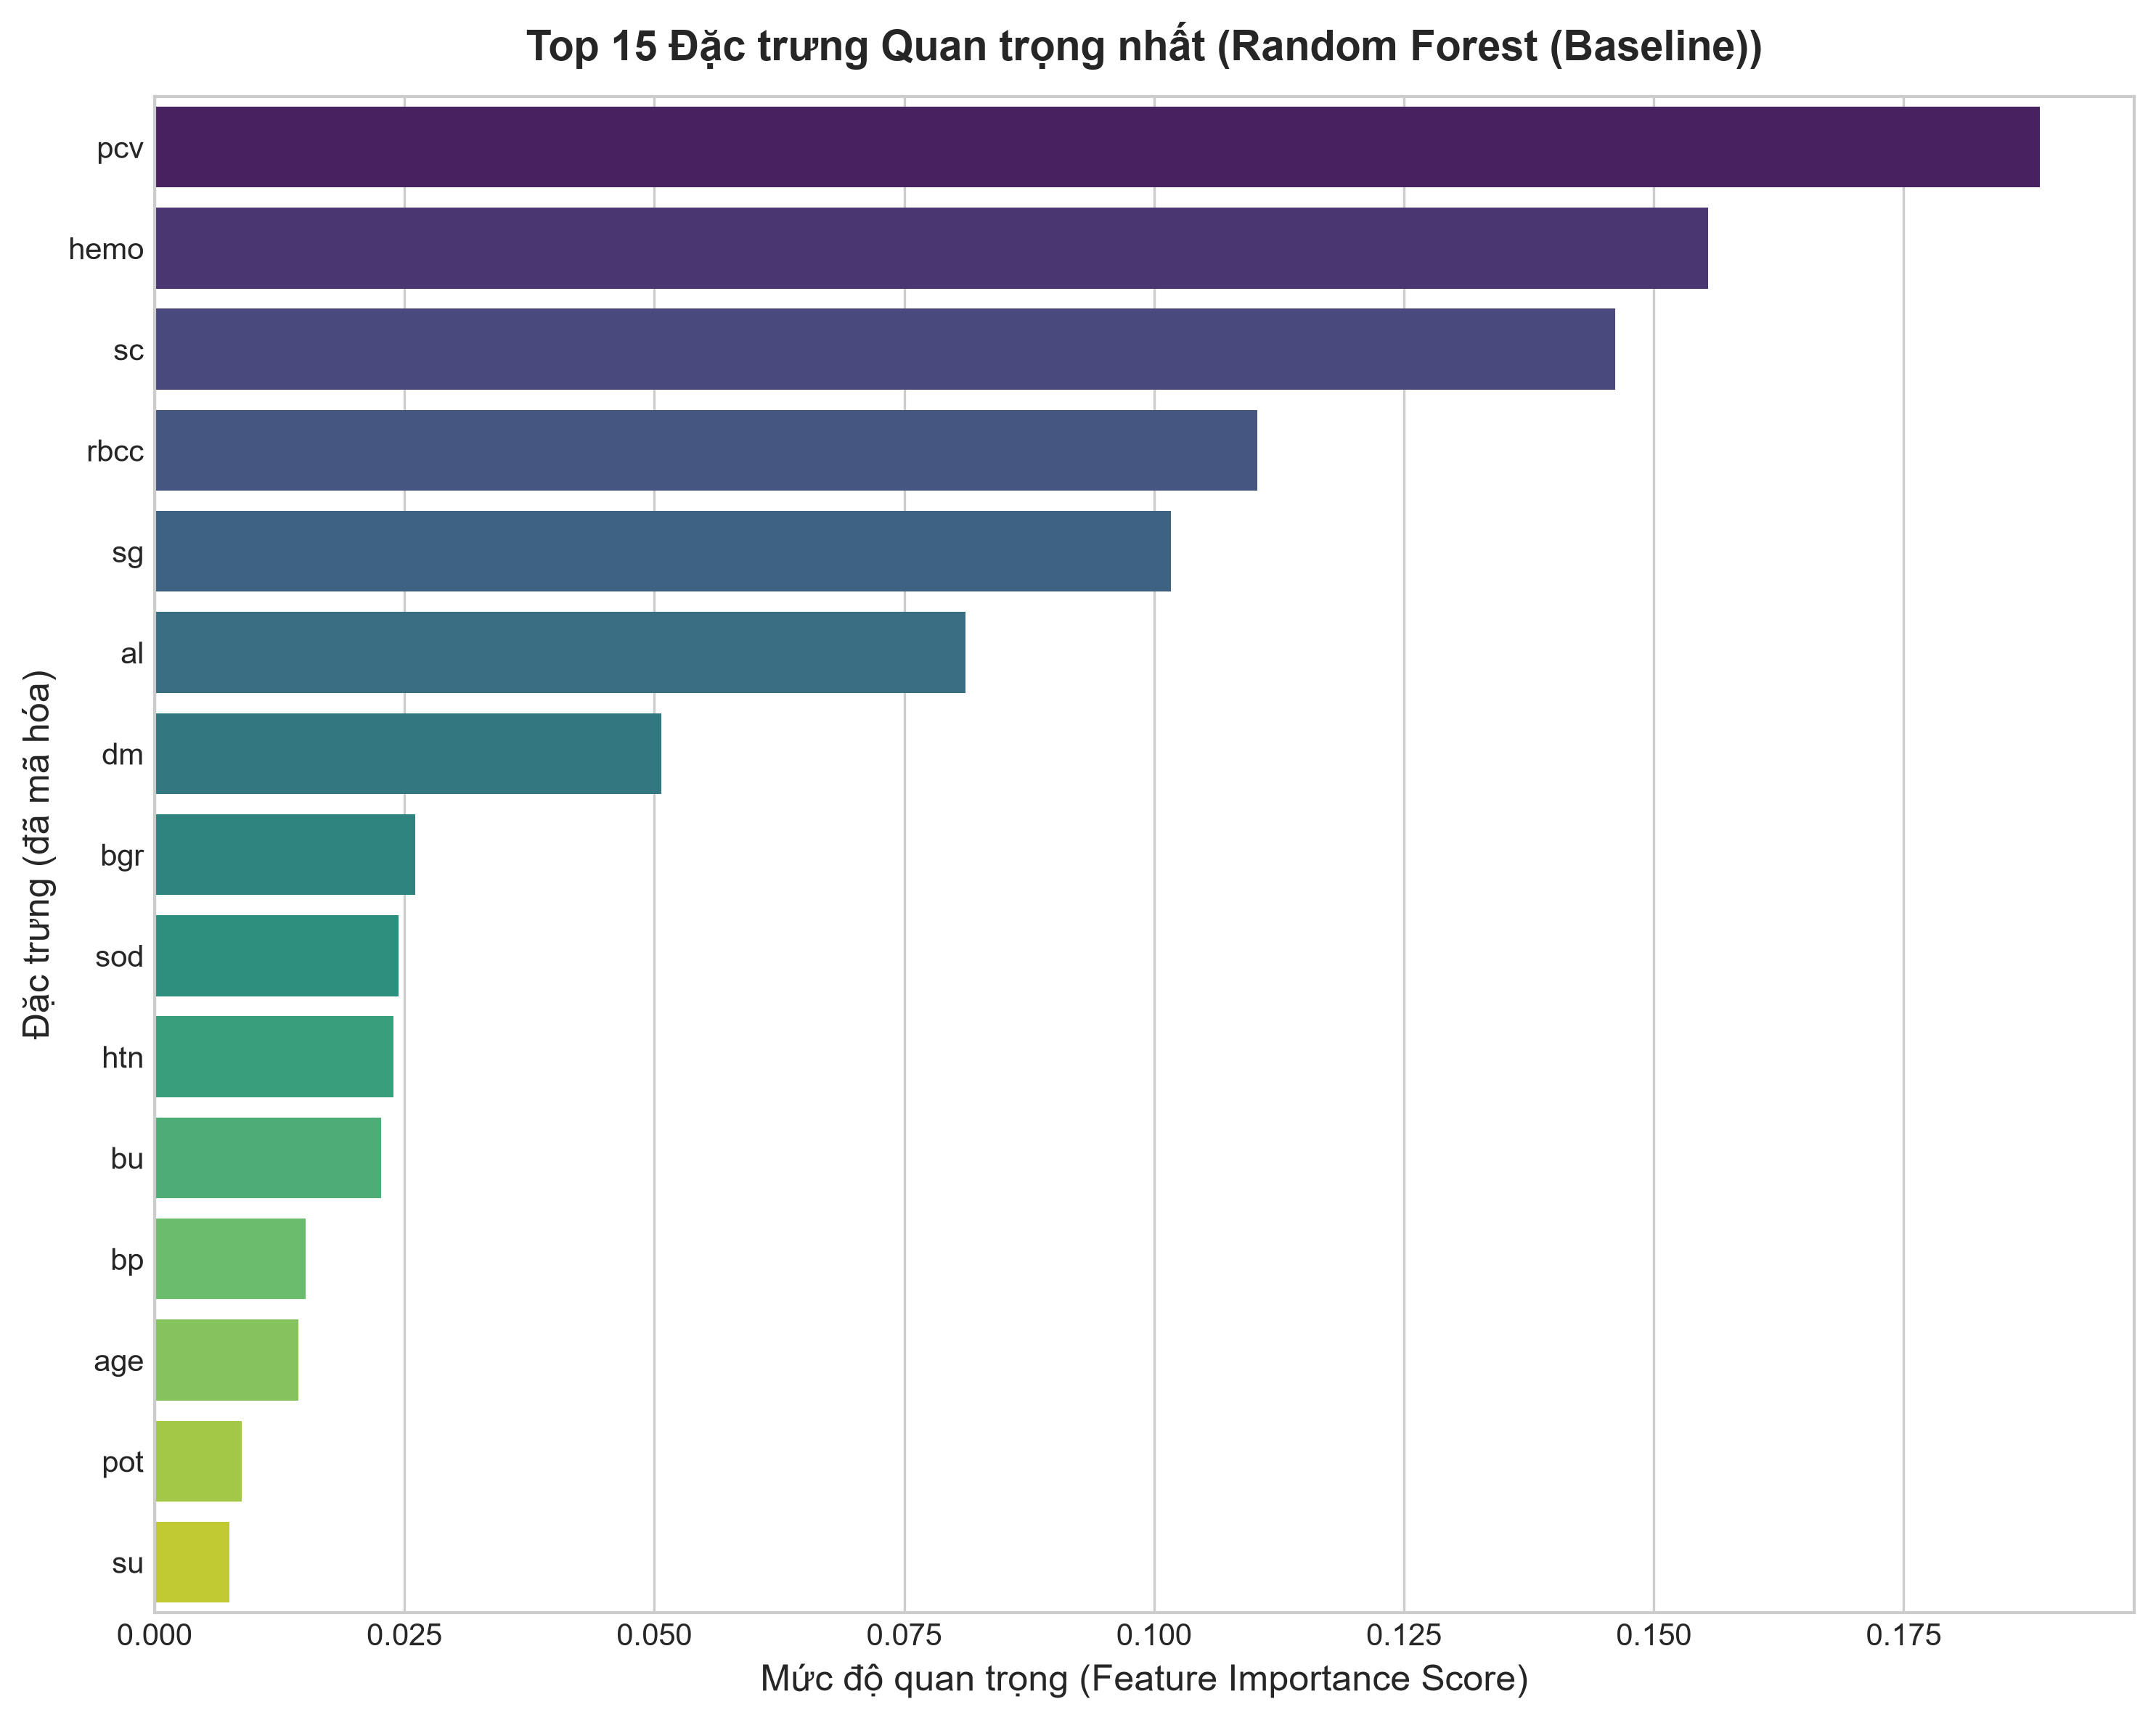

📸 Đã lưu biểu đồ Feature Importance tại: outputs/feature_importance.png
Top 5 đặc trưng có trọng số cao nhất:


,Feature,Importance
15,pcv,0.188626
14,hemo,0.155414
11,sc,0.146133
17,rbcc,0.110316
2,sg,0.101686


In [9]:
# Dùng mô hình đã chọn bằng CV (không dùng điểm test) cho Feature Importance.
best_tree_for_fi = best_model
best_tree_name = best_model_name
print(f"📌 Sử dụng mô hình [{best_tree_name}] đã chọn theo CV để trích xuất Feature Importance.")

fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree_for_fi.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8), dpi=300)
palette = sns.color_palette("viridis", n_colors=min(15, len(fi_df)))
sns.barplot(data=fi_df.head(15), x='Importance', y='Feature', palette=palette)
plt.title(f"Top 15 Đặc trưng Quan trọng nhất ({best_tree_name})", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Mức độ quan trọng (Feature Importance Score)", fontsize=12)
plt.ylabel("Đặc trưng (đã mã hóa)", fontsize=12)
plt.tight_layout()

fi_img_path = 'outputs/feature_importance.png'
plt.savefig(fi_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Đã lưu biểu đồ Feature Importance tại: {fi_img_path}")
print("Top 5 đặc trưng có trọng số cao nhất:")
display(fi_df.head(5))


### Phần 10 — Lưu mô hình, metrics và tập test bàn giao
- Chọn mô hình theo CV trên tập train; đánh giá tập test sau khi đã chốt mô hình.
- Tạo bảng test metrics cho cả nhóm cây để phục vụ so sánh trong báo cáo. Không dùng các test metrics này để đổi mô hình đã chốt.
- Lưu mô hình, metadata, bảng metrics và chính tập test dùng chung để TV3 đánh giá/XAI.


> **Ghi chú về tiêu chí chọn mô hình:**
> Mô hình được lưu vào `best_model.pkl` là mô hình có **CV Balanced Accuracy (mean) cao nhất trên tập Train** — 
> không phải mô hình có Test Accuracy cao nhất. Đây là quy trình chuẩn để tránh **Data Leakage**: 
> tập test phải được giữ kín hoàn toàn, chỉ dùng để báo cáo kết quả cuối cùng, không được dùng để chọn mô hình.
>
> Kết quả thực nghiệm:
> - **Random Forest Baseline** — CV Balanced Accuracy: **0.9892** ± 0.0181 → **Mô hình được chọn & lưu**
> - **Random Forest (Tuned)** — CV Balanced Accuracy: **0.9892** ± 0.0162 (bằng nhau, Baseline được ưu tiên do đơn giản hơn)
> - **LightGBM (Baseline)** — CV Balanced Accuracy: 0.9817 ± 0.0277 (thấp hơn, không được chọn)
> - **LightGBM (Tuned)** — CV Balanced Accuracy: 0.9867 ± 0.0152 (thấp hơn, không được chọn)
>
> LightGBM Tuned có **Test Accuracy 98.75%** cao hơn RF Baseline (97.5%) nhưng điểm CV thấp hơn.
> Nếu dùng Test Accuracy để chọn mô hình thì đã vi phạm nguyên tắc tách biệt tập test.


In [10]:
# Đánh giá cuối trên test sau khi mô hình đã được chọn bằng CV.
# Có thể báo cáo các mô hình cùng tập test, nhưng không chọn lại mô hình theo các điểm số này.
model_params = {name: estimator.get_params(deep=False) for name, estimator in model_map.items()}
model_params['Random Forest (Tuned)'] = rf_grid.best_params_
model_params['LightGBM (Tuned)'] = lgbm_grid.best_params_
comparison_rows = []
predictions_by_model = {}
for model_name, estimator in model_map.items():
    y_pred = estimator.predict(X_test)
    predictions_by_model[model_name] = y_pred
    comparison_rows.append({
        'Mô hình': model_name,
        'Cấu hình': str(model_params[model_name]),
        'CV Balanced Accuracy (mean)': cv_metrics[model_name]['mean'],
        'CV Balanced Accuracy (std)': cv_metrics[model_name]['std'],
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Test Precision CKD (class 0)': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
        'Test Recall CKD (class 0)': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        'Test F1 CKD (class 0)': f1_score(y_test, y_pred, pos_label=0, zero_division=0),
    })

summary_df = pd.DataFrame(comparison_rows).sort_values(
    by='CV Balanced Accuracy (mean)', ascending=False
).reset_index(drop=True)
print("📊 So sánh mô hình cây (xếp hạng theo CV, không theo test):")
display(summary_df)

best_test_row = summary_df.loc[summary_df['Mô hình'] == best_model_name].iloc[0]
print(f"\nMô hình đã chốt trước khi đánh giá test: {best_model_name}")
print("Confusion matrix của mô hình đã chốt (hàng = nhãn thật, cột = dự đoán; thứ tự [CKD=0, NotCKD=1]):")
display(pd.DataFrame(
    confusion_matrix(y_test, predictions_by_model[best_model_name], labels=[0, 1]),
    index=['Thật CKD (0)', 'Thật NotCKD (1)'],
    columns=['Dự đoán CKD (0)', 'Dự đoán NotCKD (1)']
))

os.makedirs('outputs', exist_ok=True)
summary_df.to_csv('outputs/model_comparison.csv', index=False, encoding='utf-8-sig')
joblib.dump(best_model, 'outputs/best_model.pkl')
joblib.dump({'X_test': X_test, 'y_test': y_test}, 'outputs/test_data.pkl')

metadata = {
    'model_name': best_model_name,
    'best_params': {
        key: (value.item() if isinstance(value, np.generic) else value)
        for key, value in model_params[best_model_name].items()
    },
    'selection_metric': '5-fold Stratified CV Balanced Accuracy on training data',
    'cv_balanced_accuracy_mean': cv_metrics[best_model_name]['mean'],
    'cv_balanced_accuracy_std': cv_metrics[best_model_name]['std'],
    'test_accuracy': float(best_test_row['Test Accuracy']),
    'test_balanced_accuracy': float(best_test_row['Test Balanced Accuracy']),
    'test_precision_ckd_class_0': float(best_test_row['Test Precision CKD (class 0)']),
    'test_recall_ckd_class_0': float(best_test_row['Test Recall CKD (class 0)']),
    'test_f1_ckd_class_0': float(best_test_row['Test F1 CKD (class 0)']),
    'target_mapping': {'0': 'CKD', '1': 'NotCKD'},
    'feature_columns': list(X.columns),
}
with open('outputs/model_metadata.json', 'w', encoding='utf-8') as metadata_file:
    json.dump(metadata, metadata_file, ensure_ascii=False, indent=2)

print("💾 Đã lưu outputs/best_model.pkl, outputs/test_data.pkl, "
      "outputs/model_comparison.csv và outputs/model_metadata.json")
print("🎉 Hoàn thành pipeline TV2; mô hình được chọn chỉ bằng CV trên tập train.")


📊 So sánh mô hình cây (xếp hạng theo CV, không theo test):


,Mô hình,Cấu hình,CV Balanced Accuracy (mean),CV Balanced Accuracy (std),Test Accuracy,Test Balanced Accuracy,Test Precision CKD (class 0),Test Recall CKD (class 0),Test F1 CKD (class 0)
0,Random Forest (Baseline),"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.989167,0.018066,0.9750,0.966667,0.961538,1.00,0.980392
1,Random Forest (Tuned),"{'max_depth': None, 'min_samples_split': 2, 'n...",0.989167,0.016159,0.9750,0.966667,0.961538,1.00,0.980392
2,LightGBM (Tuned),"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.986667,0.015230,0.9875,0.983333,0.980392,1.00,0.990099
3,LightGBM (Baseline),"{'boosting_type': 'gbdt', 'class_weight': None...",0.981667,0.027733,0.9875,0.983333,0.980392,1.00,0.990099
4,Decision Tree (Baseline),"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",0.969679,0.016312,0.9375,0.936667,0.959184,0.94,0.949495



Mô hình đã chốt trước khi đánh giá test: Random Forest (Baseline)
Confusion matrix của mô hình đã chốt (hàng = nhãn thật, cột = dự đoán; thứ tự [CKD=0, NotCKD=1]):


,Dự đoán CKD (0),Dự đoán NotCKD (1)
Thật CKD (0),50,0
Thật NotCKD (1),2,28


💾 Đã lưu outputs/best_model.pkl, outputs/test_data.pkl, outputs/model_comparison.csv và outputs/model_metadata.json
🎉 Hoàn thành pipeline TV2; mô hình được chọn chỉ bằng CV trên tập train.


### Phần 11 — Phân tích độ nhạy siêu tham số
So sánh độ chính xác trên folds huấn luyện và validation folds **chỉ trong tập train** để quan sát ảnh hưởng của `learning_rate` (LightGBM) và `max_depth` (Decision Tree). Tập test không tham gia phân tích độ nhạy hay chọn cấu hình. Các đường biểu diễn là trung bình 5 fold; độ lệch chuẩn validation được ghi trong bảng.


📊 Độ nhạy LightGBM theo learning_rate (5-fold CV trên train):


,Learning Rate,Train CV Balanced Accuracy (%),Validation CV Balanced Accuracy (%),Validation CV Std (%)
0,0.00,50.00,50.00,0.00
1,0.01,96.87,91.25,8.04
2,0.05,100.00,98.50,1.73
3,0.10,100.00,98.17,2.77
4,0.50,100.00,98.42,2.23
5,1.00,100.00,98.16,2.07


--------------------------------------------------------------------------------
📊 Độ nhạy Decision Tree theo max_depth (5-fold CV trên train):


,Max Depth,Train CV Balanced Accuracy (%),Validation CV Balanced Accuracy (%),Validation CV Std (%)
0,1,93.88,91.47,5.88
1,2,98.42,96.97,1.35
2,3,99.58,97.48,1.71
3,5,100.00,96.97,1.63
4,None,100.00,96.97,1.63


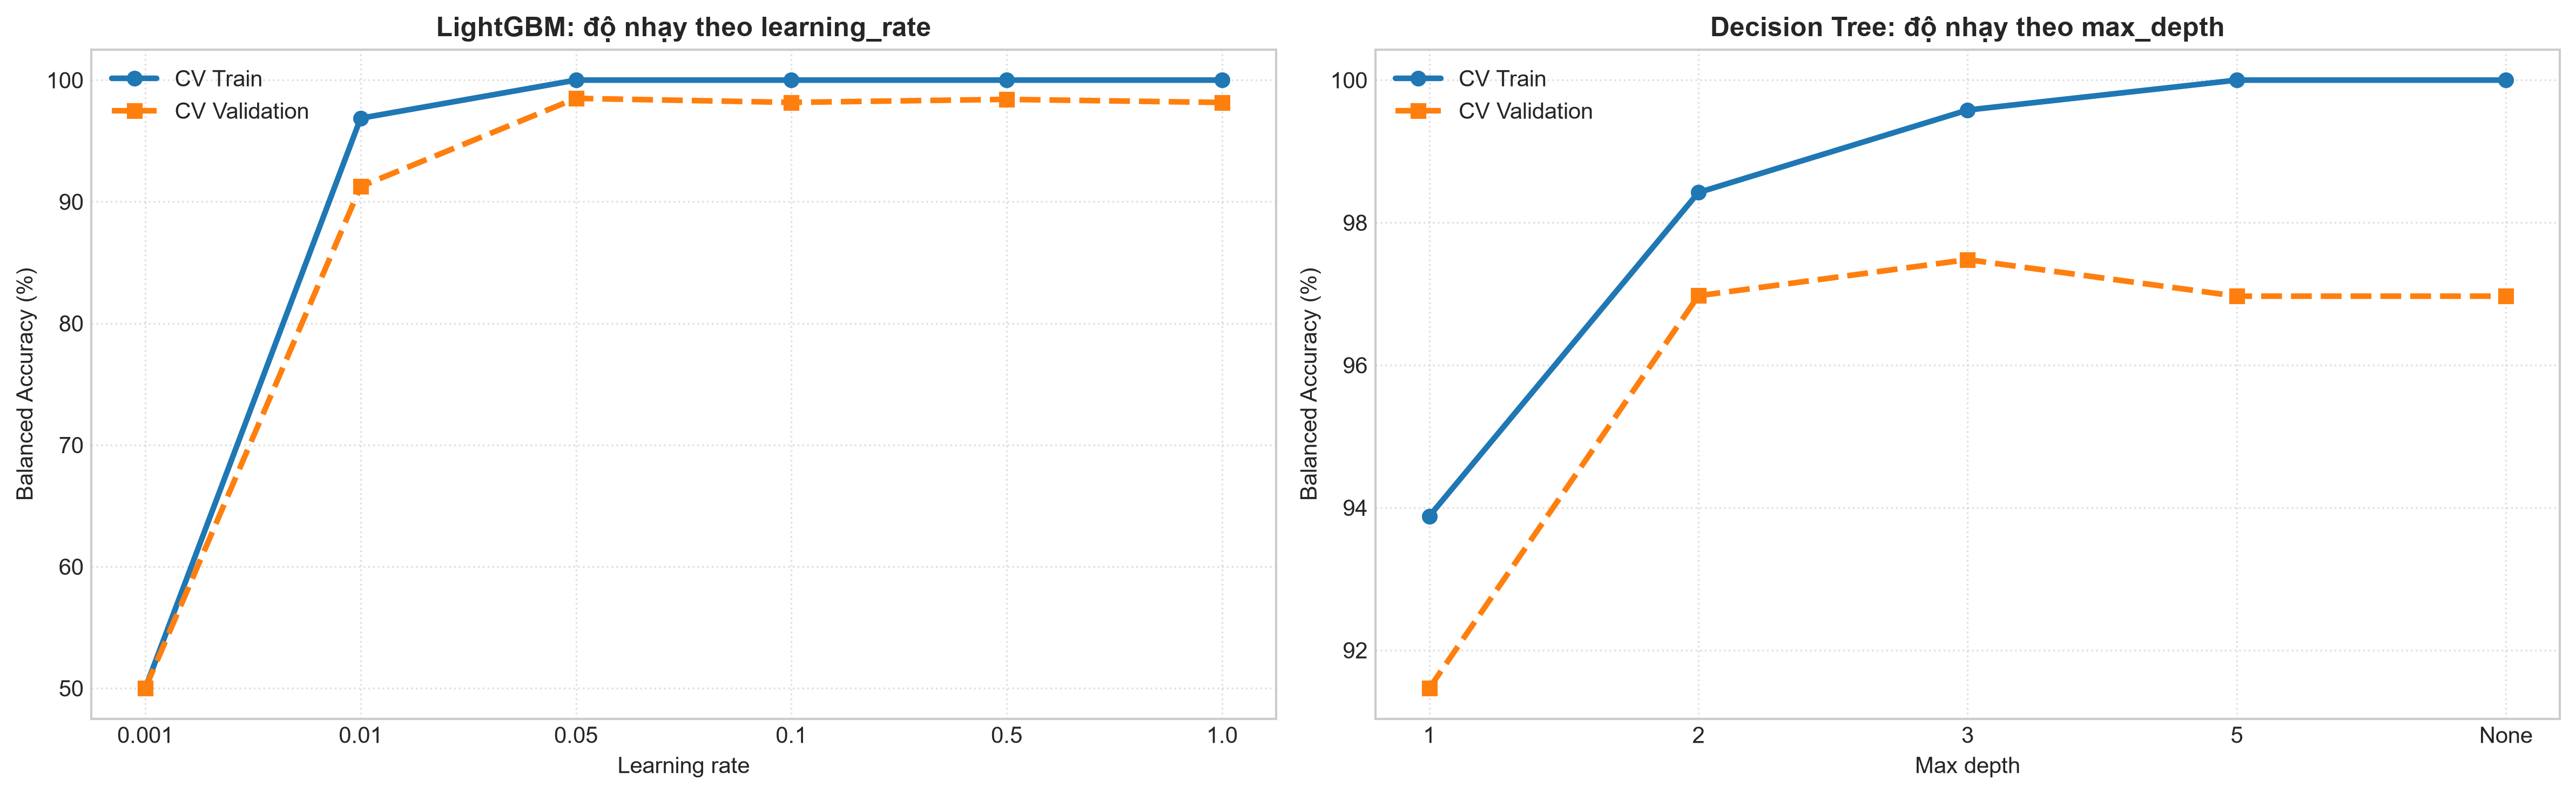

📸 Đã xuất biểu đồ độ nhạy tại: outputs/hyperparameter_sensitivity.png


In [11]:
# === PHẦN 11: PHÂN TÍCH ĐỘ NHẠY SIÊU THAM SỐ (TRAINING CV ONLY) ===

# Khảo sát learning_rate cho LightGBM; các tham số khác được giữ cố định.
lr_candidates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lgb_records = []
for lr in lr_candidates:
    estimator = LGBMClassifier(
        learning_rate=lr, n_estimators=100, random_state=42, verbose=-1
    )
    scores = cross_validate(
        estimator, X_train, y_train, cv=cv,
        scoring='balanced_accuracy', n_jobs=1,
        return_train_score=True
    )
    lgb_records.append({
        'Learning Rate': lr,
        'Train CV Balanced Accuracy (%)': scores['train_score'].mean() * 100,
        'Validation CV Balanced Accuracy (%)': scores['test_score'].mean() * 100,
        'Validation CV Std (%)': scores['test_score'].std(ddof=1) * 100,
    })

df_sensitivity_lgb = pd.DataFrame(lgb_records)
print('📊 Độ nhạy LightGBM theo learning_rate (5-fold CV trên train):')
display(df_sensitivity_lgb.round(2))
print('-' * 80)

# Khảo sát max_depth cho Decision Tree.
depth_candidates = [1, 2, 3, 5, None]
dt_records = []
for depth in depth_candidates:
    estimator = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_validate(
        estimator, X_train, y_train, cv=cv,
        scoring='balanced_accuracy', n_jobs=1,
        return_train_score=True
    )
    dt_records.append({
        'Max Depth': 'None' if depth is None else str(depth),
        'Train CV Balanced Accuracy (%)': scores['train_score'].mean() * 100,
        'Validation CV Balanced Accuracy (%)': scores['test_score'].mean() * 100,
        'Validation CV Std (%)': scores['test_score'].std(ddof=1) * 100,
    })

df_sensitivity_dt = pd.DataFrame(dt_records)
print('📊 Độ nhạy Decision Tree theo max_depth (5-fold CV trên train):')
display(df_sensitivity_dt.round(2))

# Vẽ train-vs-validation CV; không có đường test.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=300)
axes[0].plot(df_sensitivity_lgb['Learning Rate'].astype(str),
             df_sensitivity_lgb['Train CV Balanced Accuracy (%)'],
             marker='o', label='CV Train', linewidth=2.5)
axes[0].plot(df_sensitivity_lgb['Learning Rate'].astype(str),
             df_sensitivity_lgb['Validation CV Balanced Accuracy (%)'],
             marker='s', label='CV Validation', linewidth=2.5, linestyle='--')
axes[0].set_title('LightGBM: độ nhạy theo learning_rate', fontweight='bold')
axes[0].set_xlabel('Learning rate')
axes[0].set_ylabel('Balanced Accuracy (%)')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

axes[1].plot(df_sensitivity_dt['Max Depth'],
             df_sensitivity_dt['Train CV Balanced Accuracy (%)'],
             marker='o', label='CV Train', linewidth=2.5)
axes[1].plot(df_sensitivity_dt['Max Depth'],
             df_sensitivity_dt['Validation CV Balanced Accuracy (%)'],
             marker='s', label='CV Validation', linewidth=2.5, linestyle='--')
axes[1].set_title('Decision Tree: độ nhạy theo max_depth', fontweight='bold')
axes[1].set_xlabel('Max depth')
axes[1].set_ylabel('Balanced Accuracy (%)')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
sensitivity_img_path = 'outputs/hyperparameter_sensitivity.png'
plt.savefig(sensitivity_img_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'📸 Đã xuất biểu đồ độ nhạy tại: {sensitivity_img_path}')
